In [68]:
import collections

import datasets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchtext
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
import tqdm

In [2]:
seed = 1234

np.random.seed(seed)
torch.manual_seed(seed)
# torch.cuda.manual_seed(seed)
# torch.backends.cudnn.deterministic = True

In [3]:
train_data, test_data = datasets.load_dataset('imdb', split=['train', 'test'])

In [4]:
tokenizer = get_tokenizer('basic_english')

In [5]:
def tokenize_example(example, tokenizer, max_length):
    tokens = tokenizer(example['text'])[:max_length]
    length = len(tokens)
    return {'tokens': tokens, 'length': length}

In [6]:
max_length = 256

train_data = train_data.map(tokenize_example, fn_kwargs={'tokenizer': tokenizer, 'max_length': max_length})
test_data = test_data.map(tokenize_example, fn_kwargs={'tokenizer': tokenizer, 'max_length': max_length})

In [7]:
train_data

Dataset({
    features: ['text', 'label', 'tokens', 'length'],
    num_rows: 25000
})

In [8]:
valid_size = 0.25

train_valid_data = train_data.train_test_split(test_size=valid_size)
train_data = train_valid_data['train']
valid_data = train_valid_data['test']

In [9]:
min_freq = 5
special_token = ['<unk>', '<pad>']

vocab = build_vocab_from_iterator(train_data['tokens'], min_freq=min_freq, specials=special_token)

In [10]:
vocab.get_itos()

['<unk>',
 '<pad>',
 'the',
 '.',
 ',',
 'a',
 'and',
 'of',
 'to',
 "'",
 'is',
 'it',
 'i',
 'in',
 'this',
 'that',
 's',
 'was',
 'movie',
 'as',
 'with',
 'for',
 'but',
 'film',
 ')',
 '(',
 'you',
 't',
 'on',
 'not',
 'are',
 'have',
 'his',
 'he',
 'one',
 'be',
 '!',
 'all',
 'at',
 'they',
 'by',
 'an',
 'who',
 'so',
 'from',
 'like',
 'there',
 'about',
 'just',
 'or',
 'has',
 'her',
 'if',
 'out',
 'what',
 'some',
 '?',
 'good',
 'very',
 'can',
 'when',
 'my',
 'more',
 'she',
 'time',
 'story',
 'no',
 'even',
 'would',
 'really',
 'up',
 'only',
 'had',
 'which',
 'see',
 'me',
 'were',
 'their',
 'we',
 'bad',
 'well',
 'first',
 'people',
 'great',
 '-',
 'much',
 'than',
 'get',
 'been',
 'other',
 'because',
 'don',
 'do',
 'how',
 'most',
 'will',
 'into',
 'also',
 'movies',
 'made',
 'its',
 'could',
 'way',
 'after',
 'him',
 'then',
 'make',
 'think',
 'them',
 'too',
 'any',
 'characters',
 'seen',
 'watch',
 'plot',
 'films',
 'acting',
 'many',
 'two',
 '

In [11]:
unk_index = vocab['<unk>']
pad_index = vocab['<pad>']

In [12]:
vocab.set_default_index(unk_index)

In [13]:
def numericalize_example(example, vocab):
    ids = vocab.lookup_indices(example['tokens'])
    return {'ids': ids}

In [14]:
train_data = train_data.map(numericalize_example, fn_kwargs={'vocab': vocab})
test_data = test_data.map(numericalize_example, fn_kwargs={'vocab': vocab})
valid_data = valid_data.map(numericalize_example, fn_kwargs={'vocab': vocab})

In [15]:
train_data

Dataset({
    features: ['text', 'label', 'tokens', 'length', 'ids'],
    num_rows: 18750
})

In [16]:
train_data = train_data.with_format(type='torch', columns=['ids', 'label', 'length'])
valid_data = valid_data.with_format(type='torch', columns=['ids', 'label', 'length'])
test_data = test_data.with_format(type='torch', columns=['ids', 'label', 'length'])

In [17]:
train_data[0]

{'label': tensor(1),
 'length': tensor(135),
 'ids': tensor([  180,     4,    14,    10,   191,   841,    34,     7,     2,   121,
            98,   816,    50,     8,  1516,     2,   380,     7,     2,   184,
             3,     8,   805,    14,    18,    10,     8,   805,  2246,   429,
             3,    12,   347,    15,     2,   388,  1025,     9,    16,    76,
             5,    64,     7, 11198,     3,     2,  9212,    17,   761,     4,
          7812,  5460,   198,    37,     4,     6,  3653,  3683,    17,   226,
             5, 11893,     3,    53,     7,    15,  3310,   354,     5,   689,
             4,     0,  5471,     3,  2706,  3826,     9,    16,   246,    13,
            14,    18,  1111,    33,    17,   126,   188,     8,    35,   597,
           181,    19,     5,    34,  3942,  1381,    13,     2,  5370,     3,
            32,  4228,    10,    41,  2825,     8,    37,     3,     2,  4411,
          1141,   213,  2655,     6, 16946,  3729,   590,  4845,     8,  2416,


In [18]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_ids = [i['ids'] for i in batch]
        batch_ids = nn.utils.rnn.pad_sequence(batch_ids, padding_value=pad_index, batch_first=True)
        batch_length = [i['length'] for i in batch]
        batch_length = torch.stack(batch_length)
        batch_label = [i['label'] for i in batch]
        batch_label = torch.stack(batch_label)
        batch = {'ids': batch_ids, 'length': batch_length, 'label': batch_label}
        return batch
    return collate_fn

In [19]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(dataset=dataset,
                                              batch_size=batch_size,
                                              collate_fn=collate_fn,
                                              shuffle=shuffle)
    return data_loader

In [20]:
batch_size = 512

trian_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index, shuffle=False)
test_data_loader = get_data_loader(test_data, batch_size, pad_index, shuffle=False)

In [21]:
class LSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, output_dim, hidden_dim, n_layers, bidirectional, dropout_rate, pad_index):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_index)
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            n_layers,
                            bidirectional=bidirectional,
                            dropout=dropout_rate,
                            batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, ids, length):
        embedded = self.dropout(self.embedding(ids))
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, length, batch_first=True, enforce_sorted=False)
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        output, output_length = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        if self.lstm.bidirectional:
            hidden = self.dropout(torch.cat([hidden[-1], hidden[-2]], dim=-1))
        else:
            hidden = self.dropout(hidden[-1])
        prediction = self.fc(hidden)
        return prediction

In [22]:
vocab_size = len(vocab)
embedding_dim = 300
hidden_dim = 300
output_dim = len(train_data.unique('label'))
n_layer = 2
bidirectional = True
dropout_rate = 0.5

model = LSTM(vocab_size, embedding_dim, output_dim, hidden_dim, n_layer, bidirectional, dropout_rate, pad_index)

In [23]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 10,101,302 trainable parameters


In [24]:
(vocab_size * embedding_dim + # embedding层的参数
 (hidden_dim * hidden_dim + hidden_dim + embedding_dim * hidden_dim + hidden_dim) * 4 * 2 + # 底层lstm参数，4门双向
 (2*hidden_dim * hidden_dim + hidden_dim + hidden_dim * hidden_dim + hidden_dim) * 4 * 2 + # 上层lstm参数，输入是底层双向hidden的拼接，4门双向
 hidden_dim * 2 * output_dim + output_dim) # 线性层参数


10101302

In [25]:
def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)
    elif isinstance(m, nn.LSTM):
        for name, param in m.named_parameters():
            if 'weight' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

In [26]:
# for name, parm in model.lstm.named_parameters():
#     print(name, parm)

In [27]:
model.apply(initialize_weights)

LSTM(
  (embedding): Embedding(21635, 300, padding_idx=1)
  (lstm): LSTM(300, 300, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=600, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [28]:
vectors = torchtext.vocab.GloVe()

In [29]:
pretrained_embedding = vectors.get_vecs_by_tokens(vocab.get_itos())

In [30]:
model.embedding.weight.data = pretrained_embedding

In [31]:
lr = 5e-4
optimizer = optim.Adam(model.parameters(), lr=lr)

In [32]:
criterion = nn.CrossEntropyLoss()

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [34]:
model = model.to(device)
criterion = criterion.to(device)

In [35]:
def train(dataloader, model, criterion, optimizer, device):
    model.train()
    epoch_loss = []
    epoch_accs = []
    for batch in tqdm.tqdm(dataloader, desc='training...'):
        ids = batch['ids'].to(device)
        length = batch['length']
        label = batch['label'].to(device)
        prediction = model(ids, length)
        loss = criterion(prediction, label)
        accuracy = get_accuracy(prediction, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
        epoch_accs.append(accuracy.item())
    return np.mean(epoch_loss), np.mean(epoch_accs)

In [36]:
def evaluate(dataloader, model, criterion, device):
    model.eval()
    epoch_loss = []
    epoch_accs = []
    for batch in tqdm.tqdm(dataloader, desc='evaluating...'):
        ids = batch['ids'].to(device)
        length = batch['length'].to(device)
        label = batch['label'].to(device)
        prediction = model(ids, length)
        loss = criterion(prediction, label)
        accuracy = get_accuracy(prediction, label)
        epoch_loss.append(loss.item())
        epoch_accs.append(accuracy.item())
    return np.mean(epoch_loss), np.mean(epoch_accs)

In [37]:
def get_accuracy(prediction, label):
    batch_size, _ = prediction.shape
    predicted_class = prediction.argmax(dim=-1)
    correct_predictions = predicted_class.eq(label).sum()
    accuracy = correct_predictions / batch_size
    return accuracy

In [38]:
n_epoch = 10
best_valid_loss = float('inf')

metrics = collections.defaultdict(list)

for epoch in range(n_epoch):
    train_loss, train_acc = train(trian_data_loader, model, criterion, optimizer, device)
    valid_loss, valid_acc = evaluate(valid_data_loader, model, criterion, device)
    metrics['train_losses'].append(train_loss)
    metrics['train_accs'].append(train_acc)
    metrics['valid_losses'].append(valid_loss)
    metrics['valid_accs'].append(valid_acc)
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), './best_model/lstm.pt')
    print(f'epoch: {epoch + 1}')
    print(f'train_loss: {train_loss:.3f}, train_acc: {train_acc:.3f}')
    print(f'valid_loss: {valid_loss:.3f}, valid_acc: {valid_acc:.3f}')

evaluating...: 100%|██████████| 13/13 [01:18<00:00,  6.03s/it]


epoch: 1
train_loss: 0.612, train_acc: 0.655
valid_loss: 0.540, valid_acc: 0.728


evaluating...: 100%|██████████| 13/13 [01:16<00:00,  5.85s/it]


epoch: 2
train_loss: 0.480, train_acc: 0.769
valid_loss: 0.384, valid_acc: 0.830


evaluating...: 100%|██████████| 13/13 [01:15<00:00,  5.80s/it]


...

epoch: 8
train_loss: 0.242, train_acc: 0.905
valid_loss: 0.288, valid_acc: 0.887


evaluating...: 100%|██████████| 13/13 [01:15<00:00,  5.81s/it]


epoch: 9
train_loss: 0.239, train_acc: 0.906
valid_loss: 0.288, valid_acc: 0.885


evaluating...: 100%|██████████| 13/13 [01:15<00:00,  5.82s/it]

epoch: 10
train_loss: 0.229, train_acc: 0.909
valid_loss: 0.277, valid_acc: 0.891


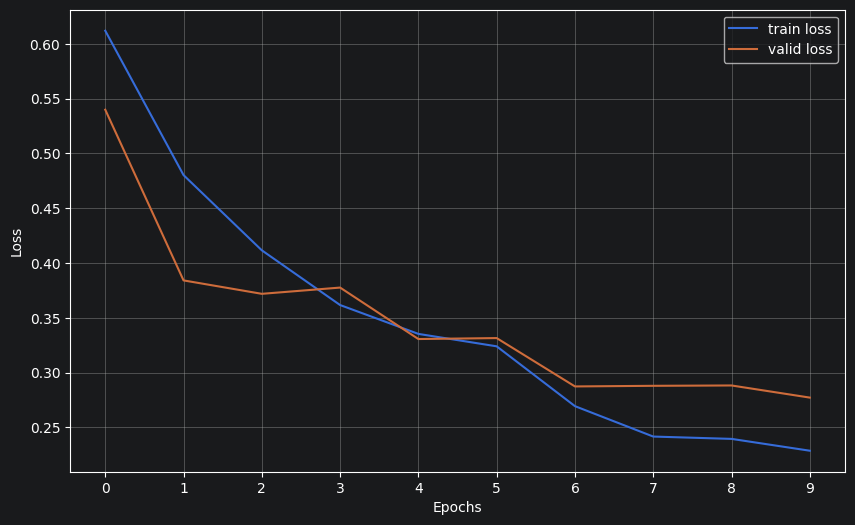

In [39]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics['train_losses'], label='train loss')
ax.plot(metrics['valid_losses'], label='valid loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_xticks(range(n_epoch))
ax.legend()
ax.grid()

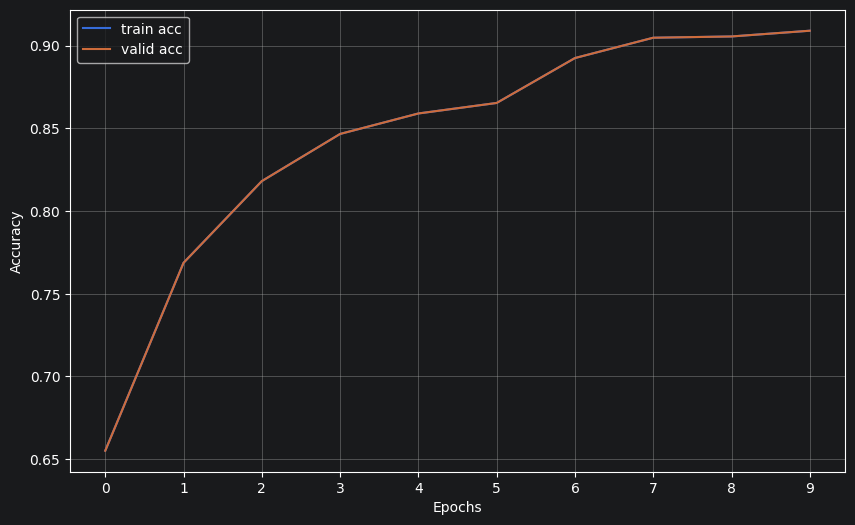

In [41]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics['train_accs'], label='train acc')
ax.plot(metrics['valid_accs'], label='valid acc')
ax.set_xlabel('Epochs')
ax.set_ylabel('Accuracy')
ax.set_xticks(range(n_epoch))
ax.legend()
ax.grid()

In [45]:
model.load_state_dict(torch.load('./best_model/lstm.pt'))
test_loss, test_accs = evaluate(test_data_loader, model, criterion, device)

evaluating...: 100%|██████████| 49/49 [04:50<00:00,  5.93s/it]


In [46]:
test_loss

0.2969431192899237

In [47]:
test_accs

0.8787535793927251

In [63]:
def predict_sentiment(text, model, tokenizer, vocab, device):
    tokens = tokenizer(text)
    ids = vocab.lookup_indices(tokens)
    length = torch.LongTensor([len(ids)]).to(device)
    tensor = torch.LongTensor(ids).unsqueeze(dim=0).to(device)
    with torch.no_grad():
        prediction = model(tensor, length).squeeze(dim=0)
    probability = torch.softmax(prediction, dim=-1)
    predicted_class = probability.argmax(dim=-1).item()
    predicted_probability = probability[predicted_class].item()
    return predicted_class, predicted_probability

In [66]:
text = 'i feel everything is abnormal'

In [67]:
predict_sentiment(text, model, tokenizer, vocab, device)

(1, 0.6045560240745544)